## TODOs: Chunking (Step 4)

- Set up imports: `HybridChunker`, `HuggingFaceTokenizer`, `AutoTokenizer`, `DoclingDocument`
- Configure `HybridChunker`: `tokenizer`, `max_tokens=512`, `merge_peers=True`
- Load the JSON saved in Step 3 back into a `DoclingDocument` object via `DoclingDocument.load_from_json(path)` (no re-parsing of the PDF)
- Run `chunker.chunk(dl_doc=doc)`, iterate over chunks, apply `chunker.contextualize()`
- Inspect chunks: count, token distribution (min/max/median), spot-check samples, check shortest/degenerate chunks
- Verify that bbox/page_no metadata is preserved per chunk (`chunk.meta.doc_items`)
- Define a Pydantic schema for a chunk in `schemas.py` (`chunk_id`, `doc_id`, `text`, `contextualized_text`, `page_no`, `bbox`, `heading_path`, `token_count`)
- Generate stable, reproducible chunk IDs
- Save chunks as JSONL (basis for caching in Step 5 and embedding in Step 6)
- Once everything works in the notebook → move the logic into `ingestion.py`

In [1]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"
import json
from docling.chunking import HybridChunker
from docling_core.transforms.chunker.tokenizer.huggingface import HuggingFaceTokenizer
from docling_core.types.doc import DoclingDocument
from backend.chunk_schema import Chunk
from pathlib import Path
from transformers import AutoTokenizer
from backend.config import settings
import jsonlines
import backend.doc_processing as hf
import matplotlib.pyplot as plt

In [ ]:
tokenizer = HuggingFaceTokenizer(
    tokenizer=AutoTokenizer.from_pretrained("BAAI/bge-m3"),
    max_tokens=512,  # explizit setzen, sonst wird model_max_length verwendet
)
hyb_chunker = HybridChunker(
    tokenizer=tokenizer,
    merge_peers=True,
)

In [58]:
print(settings.DOCUMENTS_OUT_DIR)

C:\Users\admin\Programming\RAG-Systems\classic-RAG\Classic-RAG\data\output_docs


In [ ]:
hashes = hf.hash_files(settings.DOCUMENTS_IN_DIR)

settings.CHUNKS_OUT_DIR.mkdir(parents=True, exist_ok=True)
with jsonlines.open(settings.CHUNKS_OUT_DIR/"chunks.jsonl", mode="w") as writer:
    
    for stem, doc_id in hashes:
        fp = list(settings.DOCUMENTS_OUT_DIR.glob(f"{stem}.json"))[0]
        doc = DoclingDocument.load_from_json(fp)
        
        for i,chunk in enumerate(hyb_chunker.chunk(dl_doc=doc)):
            ctx = hyb_chunker.contextualize(chunk)
            record = Chunk(
                chunk_id=str(i),
                doc_id=doc_id,
                text=chunk.text,
                contextualized_text=ctx,
                token_count=tokenizer.count_tokens(ctx),
                meta=chunk.meta
            )
            writer.write(record.model_dump(mode="json"))
    

In [61]:
chunks_path = list(settings.CHUNKS_OUT_DIR.glob("*.jsonl"))[0]
with jsonlines.open(chunks_path) as reader:
    loaded_chunks = list(reader)

In [62]:
tokens  = [tokenizer.count_tokens(chunk["contextualized_text"]) for chunk in loaded_chunks]

In [63]:
print("Number of chunks:", len(loaded_chunks))


Number of chunks: 153


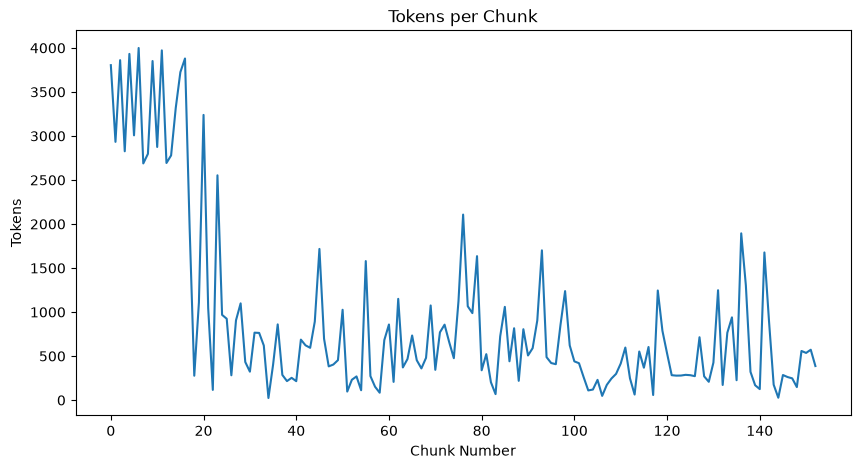

In [64]:
fig, ax = plt.subplots(figsize=(10,5))
ax.set_title(label="Tokens per Chunk")
ax.set_ylabel(ylabel="Tokens")
ax.set_xlabel(xlabel="Chunk Number")
ax.plot(range(len(loaded_chunks)), tokens )
plt.show()

### Inspecting small Chunks

In [65]:
toks_per_chunks = zip(list(range(len(loaded_chunks))), tokens)
toks_per_chunks = sorted(toks_per_chunks, key= lambda tup: tup[1])

print(toks_per_chunks[:20])

[(34, 24), (144, 27), (106, 48), (117, 58), (113, 63), (83, 68), (58, 84), (51, 97), (103, 110), (54, 112), (22, 116), (104, 120), (140, 125), (148, 148), (57, 152), (139, 169), (132, 172), (107, 173), (143, 175), (82, 203)]


In [66]:
for chunk_idx, _ in toks_per_chunks[:4]:
    print(loaded_chunks[chunk_idx]["contextualized_text"])
    print("----------------------------------------------")

ABSCHNITT 3
Pflichten der Anbieter  und  Betreiber  von Hochrisiko-KI-Systemen und anderer Beteiligter
----------------------------------------------
ANHANG X
Rechtsvorschriften  der  Union  über  IT-Großsysteme  im  Raum  der  Freiheit,  der  Sicherheit  und  des  Rechts
----------------------------------------------
Meldung von Verstößen und Schutz von Hinweisgebern
Für die Meldung von Verstößen gegen diese Verordnung und den Schutz von Personen, die solche Verstöße melden, gilt die Richtlinie  (EU)  2019/1937.
----------------------------------------------
Ausschussverfahren
- (1) Die Kommission wird von einem Ausschuss unterstützt. Dieser Ausschuss ist ein Ausschuss im Sinne der Verordnung (EU)  Nr.  182/2011.
- (2) Wird auf diesen Absatz Bezug genommen, so gilt Artikel 5 der  Verordnung (EU) Nr. 182/2011.
----------------------------------------------


In [67]:
for chunk_idx, _ in toks_per_chunks[:4]:
    print(loaded_chunks[chunk_idx]["meta"]["doc_items"])
    print("----------------------------------------------")

[{'self_ref': '#/texts/842', 'parent': {'cref': '#/body'}, 'children': [], 'content_layer': 'body', 'meta': None, 'label': 'text', 'prov': [{'page_no': 62, 'bbox': {'l': 121.889999389, 't': 748.6730311714375, 'r': 473.3690964189999, 'b': 740.0743411714376, 'coord_origin': 'BOTTOMLEFT'}, 'charspan': [0, 90]}]}]
----------------------------------------------
[{'self_ref': '#/texts/2402', 'parent': {'cref': '#/body'}, 'children': [], 'content_layer': 'body', 'meta': None, 'label': 'text', 'prov': [{'page_no': 139, 'bbox': {'l': 138.44538725200002, 't': 746.543241007254, 'r': 456.8695391251031, 'b': 739.1214796739206, 'coord_origin': 'BOTTOMLEFT'}, 'charspan': [0, 113]}]}]
----------------------------------------------
[{'self_ref': '#/texts/1838', 'parent': {'cref': '#/body'}, 'children': [], 'content_layer': 'body', 'meta': None, 'label': 'text', 'prov': [{'page_no': 110, 'bbox': {'l': 67.40929091846579, 't': 295.7360800114375, 'r': 529.7742279584658, 'b': 276.9046304414376, 'coord_origi

In [68]:
print(type(loaded_chunks[0]["meta"]))

<class 'dict'>


In [56]:
idx = toks_per_chunks[2][0]  # der dritte der vier kleinsten
print(len(loaded_chunks[idx]["text"]))
print(len(loaded_chunks[idx]["contextualized_text"]))
print(repr(loaded_chunks[idx]["text"]))

181
232
'Die in Artikel 11 Absatz 1 genannte technische Dokumentation muss mindestens die folgenden Informationen enthalten, soweit  sie  für  das  betreffende  KI-System  von  Belang  sind:'
